# Chunking experiements with CEH-GEAR-1hr rainfall data

<img width="309" height="57" alt="UKCEH and FDRI logos" src="https://github.com/user-attachments/assets/04afdc63-663f-41e4-b29d-9419f78d76c3" />
</br>

**Author** [Matt Dalle Piagge](https://mattjbr123.github.io/)

---

**Launch this notebook:**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NERC-CEH/object_store_tutorial/blob/chunkex/notebooks/gear_zarr_python.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/NERC-CEH/object_store_tutorial/HEAD?labpath=notebooks/gear_zarr_python.ipynb)

(CTRL + Click to open in a new tab)

---

## What this notebook does

This notebook consists of a simple experiment to show the difference a dataset's chunking strategy makes to the speed of an analysis when working with cloud-based gridded datasets. It uses the **CEH-GEAR-1hr** (Gridded Estimates of Areal Rainfall — Hourly), a gridded rainfall dataset for Great Britain produced as part of the [FDRI (Floods and Droughts Research Infrastructure)](https://fdri.org.uk) project.

The dataset is chunked in three ways:

- **Spatially**: 10km chunks, with no chunking in the time dimension
- **Temporally**: Daily (24-timestep) chunks, with no chunking in the spatial dimensions
- **Both:** 100km x 15day (360-timestep) chunks

And we will compare the speed of the following analyses when using these chunking options:

- **Spatial Analysis**: Extracting out a timeseries for a single spatial point
- **Temporal Analysis**: Extracting out the entire spatial domain for a single timestep

The dataset and it's chunking versions are available as a trial at the following URLs:

```
https://fdri-o.s3-ext.jc.rl.ac.uk/gearhrly-spacechunk/gearhrly_10km_chunks_all.zarr
https://fdri-o.s3-ext.jc.rl.ac.uk/gearhrly-timechunk/gearhrly_daily_chunks_all.zarr
https://fdri-o.s3-ext.jc.rl.ac.uk/gearhrly/gearhrly_15day_100km_chunks.zarr
```

---

## 0. Setup

### Google Colab

If running on Google Colab, a few extra packages need to be installed for the notebook to run properly:

In [1]:
# Install if needed (safe to run even if already installed)
%pip install -q zarr netcdf4 s3fs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 84.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.


You may see a message like "ERROR: pip's dependency resolver does not currently take into account all the packages that are installed...", but that's fine, the packages we need still get installed.

**All platforms:** Import the packages we need:

In [2]:
import xarray as xr
from dask.diagnostics import ProgressBar
import s3fs

print(f"xarray  version: {xr.__version__}")

xarray  version: 2025.12.0


---
## 1. Open the Zarr stores

`xr.open_zarr()` connects to the store over HTTPS without downloading any data yet.  

For publically available data such as this, we do not need any credentials, and instead pass anon=True which means 'access the data as an anonymous user'.

In [3]:
ds_spacechunk = xr.open_zarr(
    "s3://gearhrly-spacechunk/gearhrly_10km_chunks_all.zarr",
    storage_options={
        "anon": True,
        "endpoint_url": "https://fdri-o.s3-ext.jc.rl.ac.uk/"
    },
    consolidated=True
)

ds_timechunk = xr.open_zarr(
    "s3://gearhrly-timechunk/gearhrly_daily_chunks_all.zarr",
    storage_options={
        "anon": True,
        "endpoint_url": "https://fdri-o.s3-ext.jc.rl.ac.uk/"
    },
    consolidated=True
)

ds_bothchunk = xr.open_zarr(
    "s3://gearhrly/gearhrly_15day_100km_chunks.zarr",
    storage_options={
        "anon": True,
        "endpoint_url": "https://fdri-o.s3-ext.jc.rl.ac.uk/"
    },
    consolidated=True
)

### Check the chunking

In [6]:
ds_spacechunk.rainfall_amount.data

dask.array<open_dataset-rainfall_amount, shape=(236688, 1251, 701), dtype=float64, chunksize=(236688, 10, 10), chunktype=numpy.ndarray>

In [7]:
ds_timechunk.rainfall_amount.data

dask.array<open_dataset-rainfall_amount, shape=(236688, 1251, 701), dtype=float64, chunksize=(24, 1251, 701), chunktype=numpy.ndarray>

In [8]:
ds_bothchunk.rainfall_amount.data

dask.array<open_dataset-rainfall_amount, shape=(236688, 1251, 701), dtype=float64, chunksize=(360, 100, 100), chunktype=numpy.ndarray>

---
## 2. Time series at a single location analysis

#### With spatial chunking

Chunking  optimized for this analysis type

In [14]:
%%timeit -r 10

# Choose a location — e.g. Edinburgh, Scotland
# Adjust to any point within the dataset's extent
target_x = 500000
target_y = 200000

# Choose a time period of interest, in this example a year long
start = '2000-01-01'
end = '2000-12-31'

# The variable name — see the 'Data variables' of the view of the dataset metadata in Section 1
var_name = "rainfall_amount"

# Select the nearest grid cell
timeslice = ds_spacechunk[var_name].sel(time=slice(start, end))
point = timeslice.sel(x=target_x, y=target_y, method='nearest')

# Load the time series into memory, and persist it!
with ProgressBar():
    ts = point.compute()

[########################################] | 100% Completed | 3.13 s
[########################################] | 100% Completed | 1.83 s
[########################################] | 100% Completed | 2.03 s
[########################################] | 100% Completed | 2.13 s
[########################################] | 100% Completed | 2.12 s
[########################################] | 100% Completed | 1.43 s
[########################################] | 100% Completed | 1.73 s
[########################################] | 100% Completed | 2.03 s
[########################################] | 100% Completed | 1.82 s
[########################################] | 100% Completed | 1.42 s
[########################################] | 100% Completed | 1.43 s
2.36 s ± 345 ms per loop (mean ± std. dev. of 10 runs, 1 loop each)


#### With 'both' chunking

Chunking that isn't optimized for this analyis type

In [15]:
%%timeit -r 10

# Choose a location — e.g. Edinburgh, Scotland
# Adjust to any point within the dataset's extent
target_x = 500000
target_y = 200000

# Choose a time period of interest, same as before
start = '2000-01-01'
end = '2000-12-31'

# The variable name — see the 'Data variables' of the view of the dataset metadata in Section 1
var_name = "rainfall_amount"

# Select the nearest grid cell
timeslice = ds_bothchunk[var_name].sel(time=slice(start, end))
point = timeslice.sel(x=target_x, y=target_y, method='nearest')

# Load the time series into memory, and persist it!
with ProgressBar():
    ts = point.compute()

[########################################] | 100% Completed | 9.73 s
[########################################] | 100% Completed | 8.21 s
[########################################] | 100% Completed | 7.90 s
[########################################] | 100% Completed | 8.63 s
[########################################] | 100% Completed | 9.12 s
[########################################] | 100% Completed | 9.02 s
[########################################] | 100% Completed | 9.22 s
[########################################] | 100% Completed | 9.63 s
[########################################] | 100% Completed | 10.02 s
[########################################] | 100% Completed | 10.17 s
[########################################] | 100% Completed | 8.92 s
9.48 s ± 693 ms per loop (mean ± std. dev. of 10 runs, 1 loop each)


Plot the timeseries to see the actual data. Not included in the timed loop as it is the data extraction and download from the cloud store that we are interested in.

In [ ]:
ts.plot()

#### Results

**With optimized chunking:** 2.36s

**With unoptimized chunking:** 9.48s

**Speedup:** ~300% (4x)

---
## 3. Map at a single time step analysis

Select one time step and load the full spatial grid.

#### With temporal chunking

Chunking that is optimized for this analysis type

In [16]:
%%timeit -r 10

# Select a time step
t = "2012-01-01 00:00"
var_name = 'rainfall_amount'
hourmap = ds_timechunk[var_name].sel(time=t)

with ProgressBar():
    hourmap = hourmap.compute()

[########################################] | 100% Completed | 6.01 s
[########################################] | 100% Completed | 3.56 s
[########################################] | 100% Completed | 2.33 s
[########################################] | 100% Completed | 3.95 s
[########################################] | 100% Completed | 2.74 s
[########################################] | 100% Completed | 1.93 s
[########################################] | 100% Completed | 1.93 s
[########################################] | 100% Completed | 2.13 s
[########################################] | 100% Completed | 2.14 s
[########################################] | 100% Completed | 2.53 s
[########################################] | 100% Completed | 2.34 s
3.13 s ± 918 ms per loop (mean ± std. dev. of 10 runs, 1 loop each)


#### With 'both' chunking

Chunking that isn't optimized for this analysis type

In [17]:
 %%timeit -r 10

# Select a time step
t = "2012-01-01 00:00"
var_name = 'rainfall_amount'
hourmap = ds_bothchunk[var_name].sel(time=t)

with ProgressBar():
    hourmap = hourmap.compute()

[########################################] | 100% Completed | 63.80 s
[########################################] | 100% Completed | 65.95 s
[########################################] | 100% Completed | 62.19 s
[########################################] | 100% Completed | 61.20 s
[########################################] | 100% Completed | 60.09 s
[########################################] | 100% Completed | 61.50 s
[########################################] | 100% Completed | 61.41 s
[########################################] | 100% Completed | 61.27 s
[########################################] | 100% Completed | 61.38 s
[########################################] | 100% Completed | 59.57 s
[########################################] | 100% Completed | 59.69 s
1min 1s ± 1.72 s per loop (mean ± std. dev. of 10 runs, 1 loop each)


Plot the map to see the data. Not included in the timing loop as the data extraction and download from the cloud store is what we are interested in.

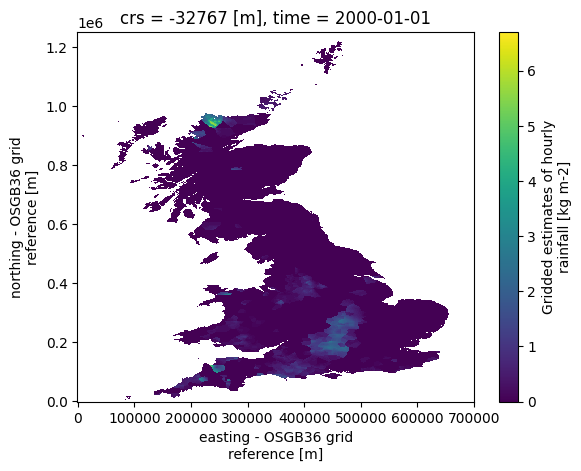

In [ ]:
hourmap.plot()

#### Results

**With optimized chunking:** 3.1s

**With unoptimized chunking:** 61s

**Speedup:** 1868% (~19.7x)

---
**Data citation:** CEH-GEAR-1hr, UKCEH. https://doi.org/10.5285/dbf13dd5-90cd-457a-a986-f2f9dd97e93c